<a href="https://colab.research.google.com/github/nemo10-boop/AlphaToeXX/blob/main/Copy_of_nnpr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

20.0

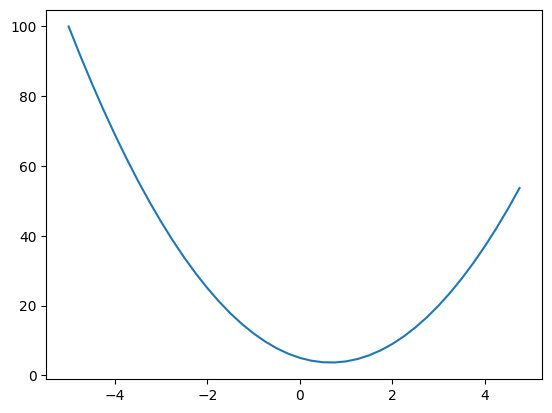

In [ ]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [ ]:
h = 0.00001
x = 3.0
(f(x+h) - f(x))/h

14.00003000000538

In [ ]:
h = 0.000000001
x = -3.0
(f(x+h) - f(x))/h

-22.000001820288162

In [ ]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.0000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.9999997
slope -2.9999999995311555


In [ ]:
c._prev

{Value(data=2.934), Value(data=3.1)}

In [ ]:
c._op

'*'

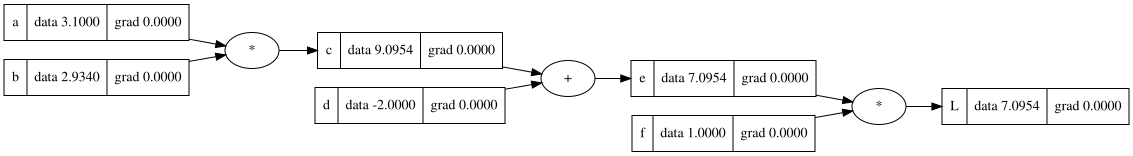

In [60]:
from graphviz import Digraph

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        # Store the gradient propagation rule for this operation.
        # During backpropagation, backward() will call out._backward()
        # to distribute gradients to this node's parents.
        self._backward = lambda: None
        # Example: if c = a * b, then c._prev = {a, b}.
        # These parent nodes are visited during backpropagation
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # Convert numbers (int/float) to Value so all operands are Value objects.
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    # Support scalar * Value by redirecting to Value * scalar
    def __rmul__(self, other):
        return self * other

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad

            out._backward = _backward
            return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        assert isinstance(self, Value)
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        assert isinstance(self, Value)
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
            out._backward = _backward
        return out

    def backward(self):
      topo = []
      visited = set()
      self.grad = 1.0
      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)
      build_topo(self)

      for node in reversed(topo):
        node._backward()


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # Node showing label, operation and data
        dot.node(
            name=uid,
            label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad),
            shape='record'
        )

        # Operation node
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    # Edges
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

# Re-instantiate 'a', 'b', 'c', 'f', and 'L' using the correct Value class defined above
a = Value(3.1, label='a')
b = Value(2.934, label='b')
c = a * b
c.label = 'c'
d = Value(-2.0, label='d')
e = c + d
e.label = 'e'
f = Value(1.0, label='f')
L = e * f
L.label = 'L'


draw_dot(L)

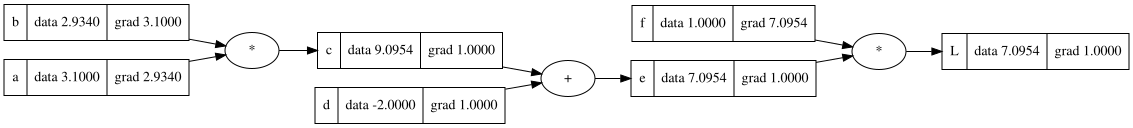

In [ ]:
L.grad =  1
e.grad = f.data
f.grad = e.data
c.grad = e.grad * 1
d.grad = e.grad * 1
b.grad = c.grad * a.data
a.grad = c.grad * b.data
draw_dot(L)

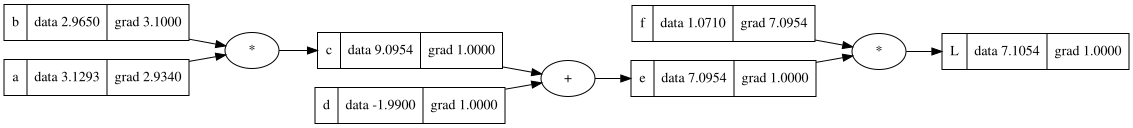

In [ ]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
d.data += 0.01 * d.grad
f.data += 0.01 * f.grad
L.data += 0.01 * L.grad
draw_dot(L)

In [ ]:
#forward pass
c = a * b
e = c + d
L = e * f
print(L.data)

17.7424801388348


In [ ]:

# L = d * r
# dL/dd =? f
# (f(x+h) - f(x))/h
# ((d+h)*f - d*f)/h
# ((d*f +h*f -d*f)/h)
# h*f/h
# f

# WANT:
# dL/dc

# KNOW:
# dL/de
# de/dc


In [ ]:
#checking how derivative is working
def lol():
  h = 0.000000001
  a = Value(3.1, label='a')
  b = Value(2.934, label='b')
  c = a * b
  c.label = 'c'
  d = Value(-2.0, label='d')
  e = c + d
  e.label = 'e'
  f = Value(1.0, label='f')
  L = e * f
  L1 = L.data

  a = Value(3.1, label='a')
  b = Value(2.934 + h, label='b')
  c = a * b
  c.label = 'c'
  d = Value(-2.0, label='d')
  e = c + d
  e.label = 'e'
  f = Value(1.0, label='f')
  L = e * f
  L2 = L.data

  print((L2 - L1)/h)

lol()



3.10000025649515


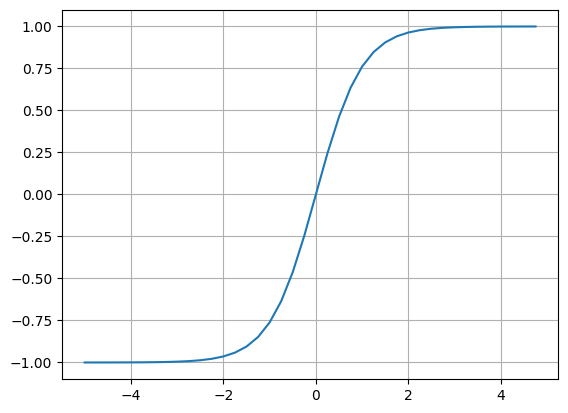

In [ ]:
plt.plot(np.arange(-5,5,0.25),np.tanh(np.arange(-5,5,0.25)))
plt.grid()

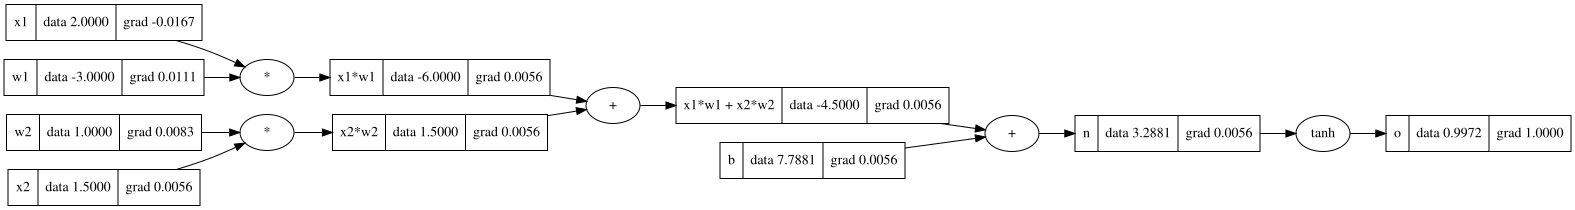

In [7]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()

draw_dot(o)

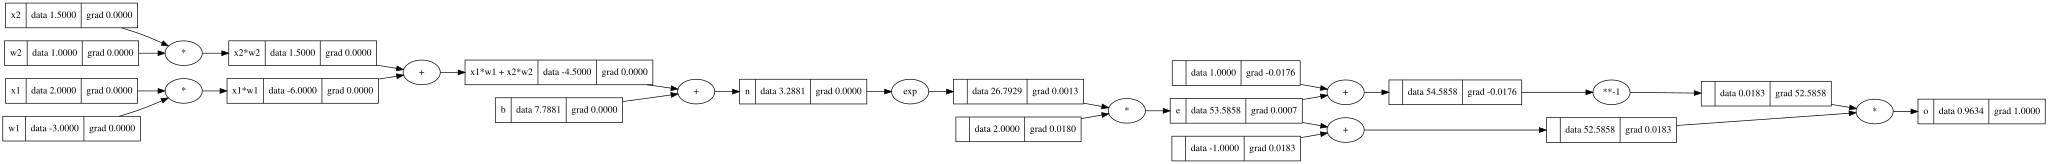

In [61]:
#input
x1 = Value(2.0, label='x1')
x2 = Value(1.5, label='x2')

#weight
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(7.78813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'

e = 2*n.exp(); e.label = 'e'
o = (e - 1)/(e + 1);

# o = n.tanh()
o.label = 'o'

o.backward()
draw_dot(o)

# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# draw_dot(o)

# o = tan(n)
# do/dn = 1 - o.data**2

# n.grad = (1 - o.data**2) * o.grad
# x1w1x2w2.grad = n.grad*1
# b.grad = n.grad*1
# x1w1.grad = x1w1x2w2.grad*1
# x2w2.grad = x1w1x2w2.grad*1
# x1.grad = x1w1.grad*w1.data
# x2.grad = x1w1.grad*w2.data
# w1.grad = x1w1.grad*x1.data
# w2.grad = x1w1.grad*x2.data
# draw_dot(o)

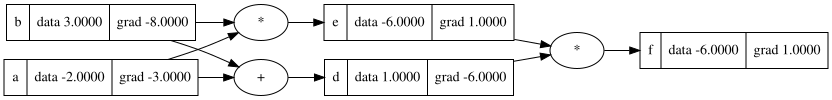

In [63]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
e = a * b;   e.label = 'e'
d = a + b;   d.label = 'd'
f = d * e;   f.label = 'f'
f.backward()
draw_dot(f)
# Example:
# a -> d -> f
# a -> e -> f
# df/da = (df/dd * dd/da) + (df/de * de/da)
# Therefore, accumulate gradients using +=.

In [64]:
# this can be easily done by deep learning library

import torch
# A tensor is essentially an n-dimensional array that stores numerical data.
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [86]:
import random

class Neuron:

  def __init__(self, nin):
    # nin = number of inputs.
    # Example: if the neuron receives [x1, x2, x3], then nin = 3,
    # so we create weights [w1, w2, w3].
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w*x + b
    # Element-wise multiply weights and inputs:
    # [w1, w2, w3] * [x1, x2, x3]
    #       ↓
    # [w1*x1, w2*x2, w3*x3]
    # Then sum all products and add the bias.

    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    # nin = number of inputs per neuron
    # nout = number of neurons
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    # return [p for neuron in self.neurons for p in neuron.parameters()]
    params = []
    for neuron in self.neurons:
      ps = neuron.parameters()
      params.extend(ps)
    return params

class MLP:

  def __init__(self, nin, nouts):
    # Combine the input size with the output sizes of each layer.
    # Example:
    # nin = 3, nouts = [4, 4, 1]
    # sz = [3, 4, 4, 1]
    # Layers created:
    # Layer(3 -> 4), Layer(4 -> 4), Layer(4 -> 1)
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, 3.3]
n = MLP(3, [4, 4, 1])
n(x)
len(n.layers[0].parameters())

16

In [92]:
xs = [
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0,-1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] #desired target

for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  #backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  #update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

0 0.00036465957037934026
1 0.000362144772862165
2 0.0003596631213781818
3 0.0003572139720311151
4 0.0003547966974269365
5 0.00035241068614959596
6 0.00035005534225655583
7 0.00034773008479326603
8 0.00034543434732587866
9 0.00034316757749121177
10 0.00034092923656343487
11 0.00033871879903655253
12 0.0003365357522222067
13 0.000334379595862022
14 0.0003322498417538869
15 0.00033014601339168134
16 0.00032806764561779753
17 0.00032601428428799
18 0.0003239854859479763
19 0.00032198081752140927
